In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn statsmodels arch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 10.7 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import date
from itertools import product as iproduct

import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import VECM, select_coint_rank
from arch import arch_model
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error,
                             mean_absolute_percentage_error)

# ── 한글 폰트 ────────────────────────────────────────────────────────────────
!apt-get install -y fonts-nanum -q > /dev/null 2>&1
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 시드 고정 ─────────────────────────────────────────────────────────────────
np.random.seed(42)

print("✅ Import 완료")

✅ Import 완료


In [3]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 한글 폰트 설치 및 설정
!apt-get install -y fonts-nanum -q
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)

# 전역 폰트 설정 적용
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

print("✅ 한글 폰트(NanumBarunGothic) 설정 및 그래프 적용 완료")

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
✅ 한글 폰트(NanumBarunGothic) 설정 및 그래프 적용 완료


In [4]:
# ── 실행일 기준 동적 날짜 계산 ────────────────────────────────────────────────
RUN_DATE     = pd.Timestamp(date.today())
TEST_START   = RUN_DATE - pd.DateOffset(months=1)
FORECAST_END = RUN_DATE + pd.DateOffset(months=1)

print(f"실행일      : {RUN_DATE.date()}")
print(f"테스트 시작 : {TEST_START.date()}")
print(f"예측 종료   : {FORECAST_END.date()}")

# ── 학습 시점 구간 (실행일 기준 동적 계산, 8가지) ─────────────────────────────
TRAIN_WINDOWS = {
    'Super_Short': (RUN_DATE - pd.DateOffset(months=6) ).strftime('%Y-%m-%d'),
    'Short'      : (RUN_DATE - pd.DateOffset(months=18)).strftime('%Y-%m-%d'),
    'Mid_Short'  : (RUN_DATE - pd.DateOffset(months=24)).strftime('%Y-%m-%d'),
    'Recent'     : (RUN_DATE - pd.DateOffset(months=30)).strftime('%Y-%m-%d'),
    'Mid'        : (RUN_DATE - pd.DateOffset(months=36)).strftime('%Y-%m-%d'),
    'Mid_Long'   : (RUN_DATE - pd.DateOffset(months=42)).strftime('%Y-%m-%d'),
    'Long'       : (RUN_DATE - pd.DateOffset(months=48)).strftime('%Y-%m-%d'),
    'Full'       : '2020-01-01',
}

MIN_TRAIN_DAYS = 30  # 최소 학습 거래일

print("\n학습 구간 설정:")
for k, v in TRAIN_WINDOWS.items():
    print(f"  {k:12s}: {v} ~")

실행일      : 2026-06-04
테스트 시작 : 2026-05-04
예측 종료   : 2026-07-04

학습 구간 설정:
  Super_Short : 2025-12-04 ~
  Short       : 2024-12-04 ~
  Mid_Short   : 2024-06-04 ~
  Recent      : 2023-12-04 ~
  Mid         : 2023-06-04 ~
  Mid_Long    : 2022-12-04 ~
  Long        : 2022-06-04 ~
  Full        : 2020-01-01 ~


In [5]:
# ── 종목 정의 ─────────────────────────────────────────────────────────────────
TICKERS = {
    '000270': ('기아',           '000270.KS'),
    '000660': ('SK하이닉스',     '000660.KS'),
    '005380': ('현대차',         '005380.KS'),
    '005930': ('삼성전자',       '005930.KS'),
    '012450': ('한화에어로스페이스', '012450.KS'),
    '051910': ('LG화학',         '051910.KS'),
    '055550': ('신한지주',       '055550.KS'),
    '079550': ('LIG넥스원',      '079550.KS'),
    '096770': ('SK이노베이션',   '096770.KS'),
    '105560': ('KB금융',         '105560.KS'),
    'KOSPI200': ('KOSPI200',     '^KS200'),
}

START_DATE = '2020-01-01'
END_DATE   = RUN_DATE.strftime('%Y-%m-%d')

raw_data = {}
for code, (name, yf_ticker) in TICKERS.items():
    df = yf.download(yf_ticker, start=START_DATE, end=END_DATE,
                     auto_adjust=True, progress=False)
    if not df.empty:
        close = df[['Close']].rename(columns={'Close': 'close'})
        vol   = df[['Volume']].rename(columns={'Volume': 'volume'}) \
                if 'Volume' in df.columns else None
        raw_data[code] = {
            'name'  : name,
            'df'    : close.dropna(),
            'volume': vol.dropna() if vol is not None else None,
        }
        print(f"  ✅ {name:20s}({code}): {len(close):4d}일")

print("\n✅ 주가 데이터 다운로드 완료")

  ✅ 기아                  (000270): 1571일
  ✅ SK하이닉스              (000660): 1571일
  ✅ 현대차                 (005380): 1571일
  ✅ 삼성전자                (005930): 1571일
  ✅ 한화에어로스페이스           (012450): 1571일
  ✅ LG화학                (051910): 1571일
  ✅ 신한지주                (055550): 1571일
  ✅ LIG넥스원              (079550): 1571일
  ✅ SK이노베이션             (096770): 1571일
  ✅ KB금융                (105560): 1571일
  ✅ KOSPI200            (KOSPI200): 1572일

✅ 주가 데이터 다운로드 완료


In [6]:
# ── 외생변수 다운로드 ─────────────────────────────────────────────────────────
EXOG_TICKERS = {
    'USDKRW': 'KRW=X',
    'WTI'   : 'CL=F',
    'VIX'   : '^VIX',
}

exog_raw = {}
for name, ticker in EXOG_TICKERS.items():
    df = yf.download(ticker, start=START_DATE, end=END_DATE,
                     auto_adjust=True, progress=False)
    if not df.empty:
        exog_raw[name] = df[['Close']].rename(columns={'Close': name})
        print(f"  ✅ {name:10s}: {len(df):4d}일")

exog_df = pd.concat(exog_raw.values(), axis=1).ffill().bfill()

# ── 종목별 통합 패널 생성 ─────────────────────────────────────────────────────
kospi_close = raw_data['KOSPI200']['df'].rename(columns={'close': 'KOSPI200'})

panels = {}
for code in raw_data:
    if code == 'KOSPI200':
        continue
    base = raw_data[code]['df'].copy()
    if raw_data[code]['volume'] is not None:
        base = base.join(raw_data[code]['volume'], how='left')
    base = base.join(kospi_close, how='left')
    base = base.join(exog_df,     how='left')
    base = base.ffill().bfill().dropna()
    panels[code] = base
    print(f"  {raw_data[code]['name']:20s}: {base.shape} | cols={list(base.columns)}")

print("\n✅ 패널 생성 완료")

  ✅ USDKRW    : 1671일
  ✅ WTI       : 1615일
  ✅ VIX       : 1614일
  기아                  : (1571, 6) | cols=[('close', '000270.KS'), ('volume', '000270.KS'), ('KOSPI200', '^KS200'), ('USDKRW', 'KRW=X'), ('WTI', 'CL=F'), ('VIX', '^VIX')]
  SK하이닉스              : (1571, 6) | cols=[('close', '000660.KS'), ('volume', '000660.KS'), ('KOSPI200', '^KS200'), ('USDKRW', 'KRW=X'), ('WTI', 'CL=F'), ('VIX', '^VIX')]
  현대차                 : (1571, 6) | cols=[('close', '005380.KS'), ('volume', '005380.KS'), ('KOSPI200', '^KS200'), ('USDKRW', 'KRW=X'), ('WTI', 'CL=F'), ('VIX', '^VIX')]
  삼성전자                : (1571, 6) | cols=[('close', '005930.KS'), ('volume', '005930.KS'), ('KOSPI200', '^KS200'), ('USDKRW', 'KRW=X'), ('WTI', 'CL=F'), ('VIX', '^VIX')]
  한화에어로스페이스           : (1571, 6) | cols=[('close', '012450.KS'), ('volume', '012450.KS'), ('KOSPI200', '^KS200'), ('USDKRW', 'KRW=X'), ('WTI', 'CL=F'), ('VIX', '^VIX')]
  LG화학                : (1571, 6) | cols=[('close', '051910.KS'), ('volume', '051910

In [7]:
# ── 분할 함수 ─────────────────────────────────────────────────────────────────
def split_data(series, train_start, test_start):
    train = series.loc[train_start : test_start - pd.Timedelta(days=1)]
    test  = series.loc[test_start :]
    return train, test

def split_panel(df, train_start, test_start):
    train = df.loc[train_start : test_start - pd.Timedelta(days=1)]
    test  = df.loc[test_start :]
    return train, test

# ── 평가 함수 ─────────────────────────────────────────────────────────────────
def evaluate(actual, predicted, model_name='', window=''):
    actual    = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()
    n = min(len(actual), len(predicted))
    if n == 0:
        return None
    a, p = actual[:n], predicted[:n]
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    mape = mean_absolute_percentage_error(a, p) * 100
    return {'model': model_name, 'window': window,
            'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE(%)': round(mape, 2)}

# ── 단변량 전처리 (8가지) ─────────────────────────────────────────────────────
PREPROCESS = {
    'raw'       : lambda s: s,
    'log'       : lambda s: np.log(s),
    'diff1'     : lambda s: s.diff().dropna(),
    'ret'       : lambda s: np.log(s).diff().dropna(),
    'diff2'     : lambda s: s.diff().diff().dropna(),
    'log_diff2' : lambda s: np.log(s).diff().diff().dropna(),
    'seas5'     : lambda s: s.diff(5).dropna(),
    'log_seas5' : lambda s: np.log(s).diff(5).dropna(),
}

def get_last_vals(train_raw):
    """역변환에 필요한 마지막 값들 계산"""
    return {
        'last_price'  : train_raw.iloc[-1],
        'last_d1'     : train_raw.diff().dropna().iloc[-1],
        'last_log'    : np.log(train_raw).iloc[-1],
        'last_log_d1' : np.log(train_raw).diff().dropna().iloc[-1],
        'last5'       : train_raw.values[-5:],
        'last5_log'   : np.log(train_raw).values[-5:],
    }

def inverse_transform(pred_arr, pp_name, last_vals):
    """예측값을 원래 주가 스케일로 역변환"""
    pred_arr = np.array(pred_arr)
    if pp_name == 'raw':
        return pred_arr
    elif pp_name == 'log':
        return np.exp(pred_arr)
    elif pp_name == 'diff1':
        return last_vals['last_price'] + np.cumsum(pred_arr)
    elif pp_name == 'ret':
        return last_vals['last_price'] * np.exp(np.cumsum(pred_arr))
    elif pp_name == 'diff2':
        d1_restored = last_vals['last_d1'] + np.cumsum(pred_arr)
        return last_vals['last_price'] + np.cumsum(d1_restored)
    elif pp_name == 'log_diff2':
        log_d1_restored = last_vals['last_log_d1'] + np.cumsum(pred_arr)
        log_restored    = last_vals['last_log']     + np.cumsum(log_d1_restored)
        return np.exp(log_restored)
    elif pp_name == 'seas5':
        buf = list(last_vals['last5'])
        restored = []
        for v in pred_arr:
            restored.append(buf[-5] + v)
            buf.append(restored[-1])
        return np.array(restored)
    elif pp_name == 'log_seas5':
        buf = list(last_vals['last5_log'])
        restored = []
        for v in pred_arr:
            restored.append(buf[-5] + v)
            buf.append(restored[-1])
        return np.exp(np.array(restored))
    return pred_arr

# ── 다변량 차분 옵션 (3가지) ──────────────────────────────────────────────────
DIFF_OPTIONS = {
    'level'  : lambda df: df,
    'd1'     : lambda df: df.diff().dropna(),
    'log_d1' : lambda df: np.log(df).diff().dropna(),
}

def inverse_transform_var(pred_col, diff_name, last_price, last_log_price):
    pred_col = np.array(pred_col)
    if diff_name == 'level':
        return pred_col
    elif diff_name == 'd1':
        return last_price + np.cumsum(pred_col)
    elif diff_name == 'log_d1':
        return np.exp(last_log_price + np.cumsum(pred_col))
    return pred_col

# ── 다변량 컬럼 조합: close+volume 고정, 나머지 4개 2^4=16가지 ─────────────────
OPTIONAL_COLS = ['KOSPI200', 'USDKRW', 'WTI', 'VIX']
FIXED_COLS    = ['close', 'volume']

COL_SETS = {}
for bits in range(16):
    chosen = [OPTIONAL_COLS[i] for i in range(4) if (bits >> i) & 1]
    key = 'base' if not chosen else '+'.join(chosen)
    COL_SETS[key] = FIXED_COLS + chosen

print(f"단변량 전처리 조합 : {len(PREPROCESS)}가지")
print(f"다변량 컬럼 조합   : {len(COL_SETS)}가지")
print(f"다변량 차분 옵션   : {len(DIFF_OPTIONS)}가지")
print("✅ 유틸리티 + 전처리 함수 정의 완료")

단변량 전처리 조합 : 8가지
다변량 컬럼 조합   : 16가지
다변량 차분 옵션   : 3가지
✅ 유틸리티 + 전처리 함수 정의 완료


In [8]:
import pandas as pd

# 이전 세션에서 저장된 최적 모델 정보
BEST_MODELS_ARCHIVE = {
    'KB금융': {'model_type': 'ARIMA(3, 0, 0)', 'preprocess': 'log', 'train_window': 'Super_Short', 'exog_set': 'Univariate', 'mape': '1.56%'},
    '신한지주': {'model_type': 'ARIMA(1, 0, 1)', 'preprocess': 'log', 'train_window': 'Super_Short', 'exog_set': 'Univariate', 'mape': '2.08%'},
    '기아': {'model_type': 'VECM', 'preprocess': 'None/Level', 'train_window': 'Long', 'exog_set': 'KOSPI200+USDKRW+VIX', 'mape': '3.57%'},
    '한화에어로스페이스': {'model_type': 'ARIMA(0, 0, 3)', 'preprocess': 'raw', 'train_window': 'Super_Short', 'exog_set': 'Univariate', 'mape': '4.06%'},
    'LG화학': {'model_type': 'ARIMA(1, 1, 1)', 'preprocess': 'log', 'train_window': 'Super_Short', 'exog_set': 'Univariate', 'mape': '5.26%'},
    'SK이노베이션': {'model_type': 'ARIMA(0, 0, 3)', 'preprocess': 'raw', 'train_window': 'Super_Short', 'exog_set': 'Univariate', 'mape': '5.36%'},
    'LIG넥스원': {'model_type': 'VECM', 'preprocess': 'None/Level', 'train_window': 'Mid', 'exog_set': 'KOSPI200+WTI+VIX', 'mape': '5.7%'},
    '현대차': {'model_type': 'ARIMA(2, 0, 2)', 'preprocess': 'log_seas5', 'train_window': 'Super_Short', 'exog_set': 'Univariate', 'mape': '10.59%'},
    '삼성전자': {'model_type': 'ARIMA(3, 0, 0)', 'preprocess': 'log', 'train_window': 'Full', 'exog_set': 'Univariate', 'mape': '15.63%'},
    'SK하이닉스': {'model_type': 'ES(mul,d)', 'preprocess': 'log', 'train_window': 'Super_Short', 'exog_set': 'Univariate', 'mape': '21.09%'}
}

print("✅ 최적 모델 설정이 로드되었습니다. 탐색 없이 시각화로 바로 넘어갈 수 있습니다.")
display(pd.DataFrame(BEST_MODELS_ARCHIVE).T)

✅ 최적 모델 설정이 로드되었습니다. 탐색 없이 시각화로 바로 넘어갈 수 있습니다.


,model_type,preprocess,train_window,exog_set,mape
KB금융,"ARIMA(3, 0, 0)",log,Super_Short,Univariate,1.56%
신한지주,"ARIMA(1, 0, 1)",log,Super_Short,Univariate,2.08%
기아,VECM,None/Level,Long,KOSPI200+USDKRW+VIX,3.57%
한화에어로스페이스,"ARIMA(0, 0, 3)",raw,Super_Short,Univariate,4.06%
LG화학,"ARIMA(1, 1, 1)",log,Super_Short,Univariate,5.26%
SK이노베이션,"ARIMA(0, 0, 3)",raw,Super_Short,Univariate,5.36%
LIG넥스원,VECM,None/Level,Mid,KOSPI200+WTI+VIX,5.7%
현대차,"ARIMA(2, 0, 2)",log_seas5,Super_Short,Univariate,10.59%
삼성전자,"ARIMA(3, 0, 0)",log,Full,Univariate,15.63%
SK하이닉스,"ES(mul,d)",log,Super_Short,Univariate,21.09%


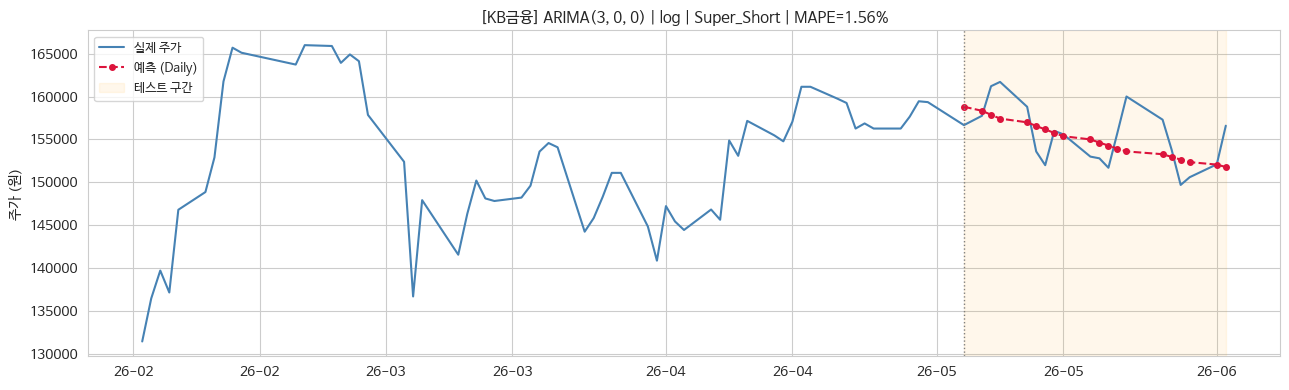

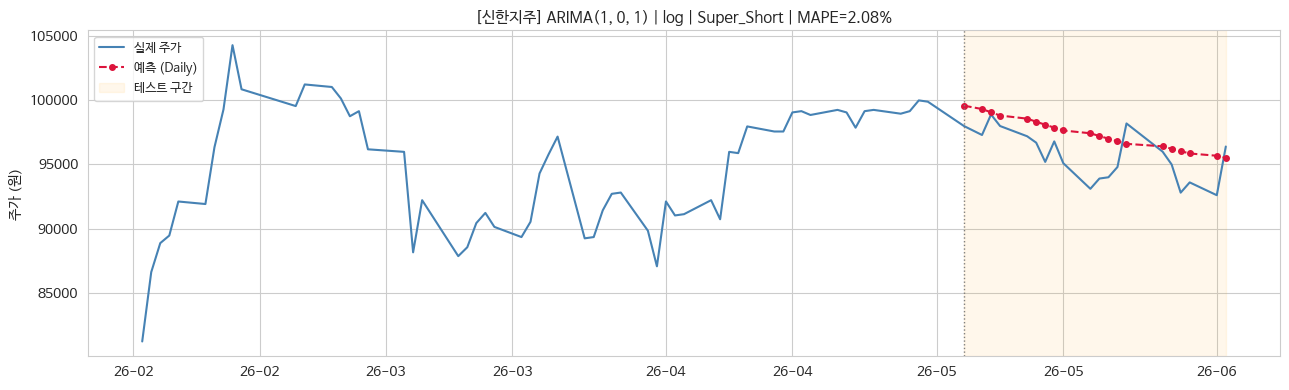

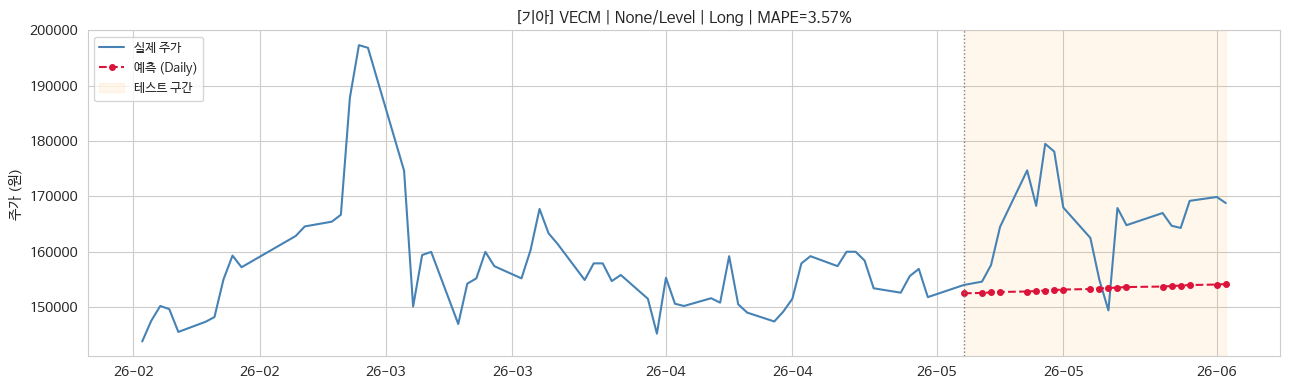

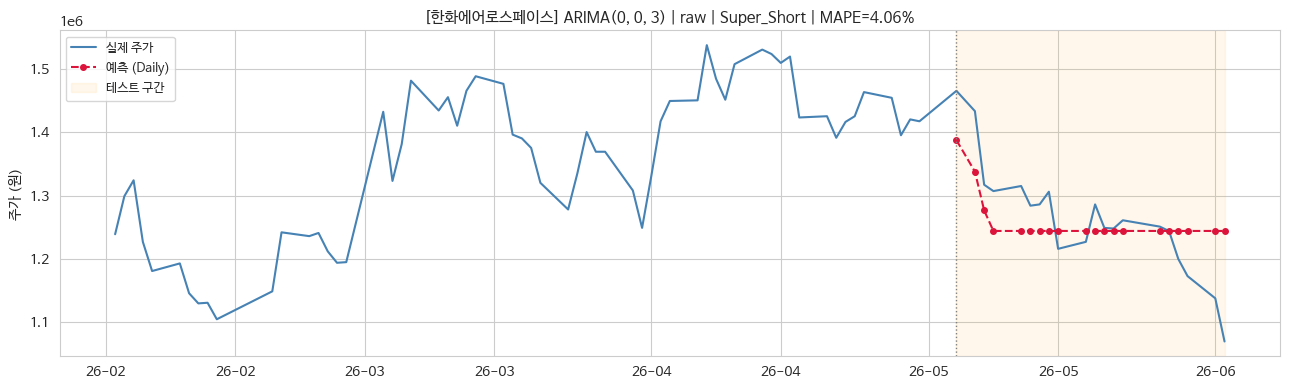

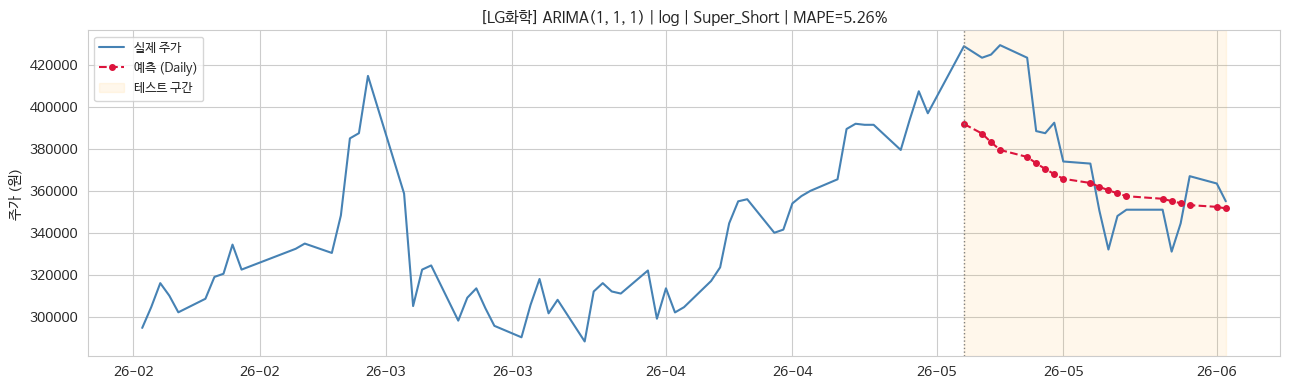

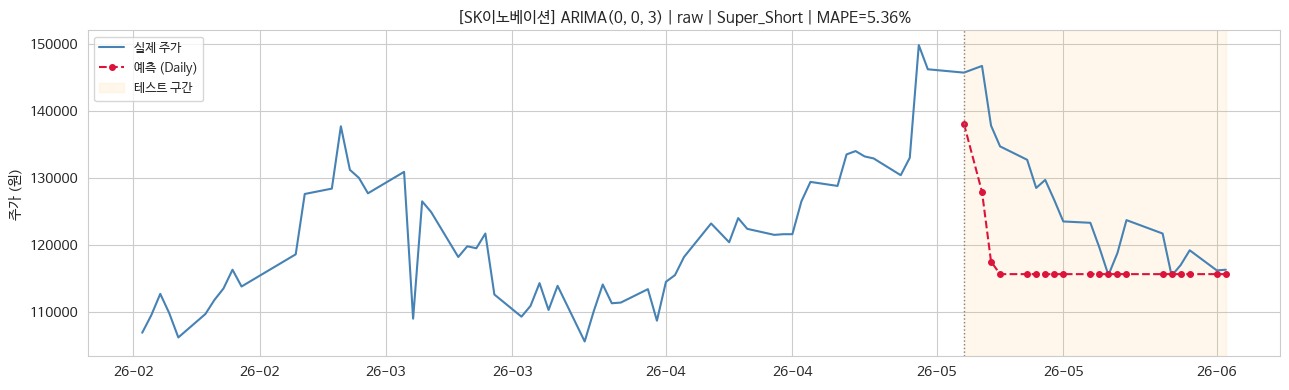

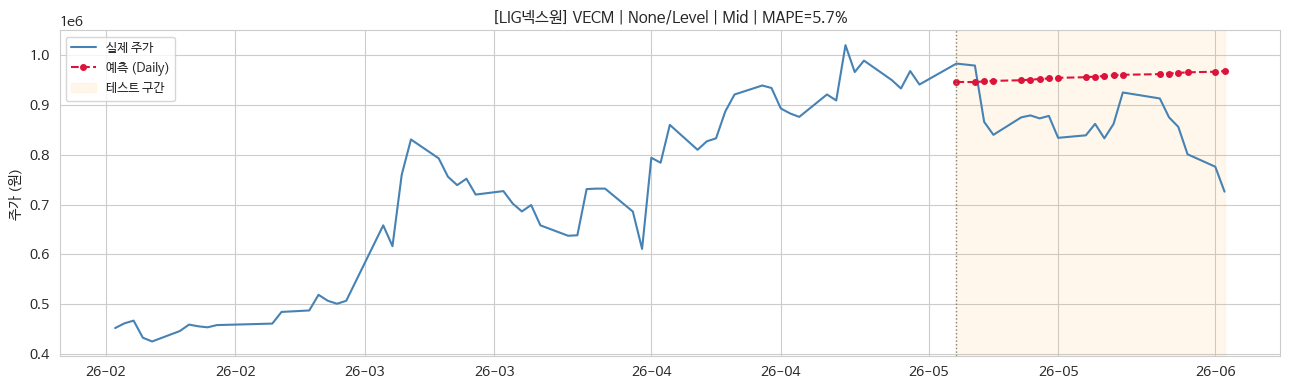

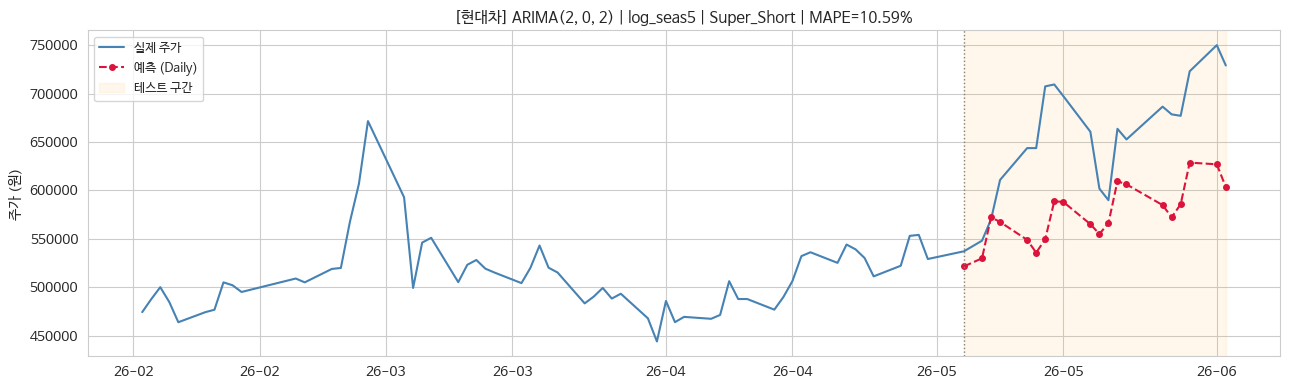

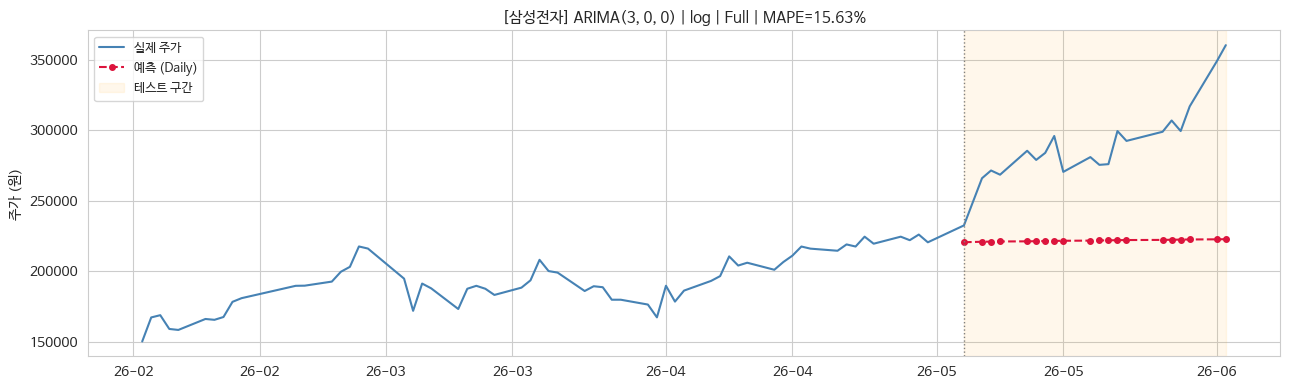

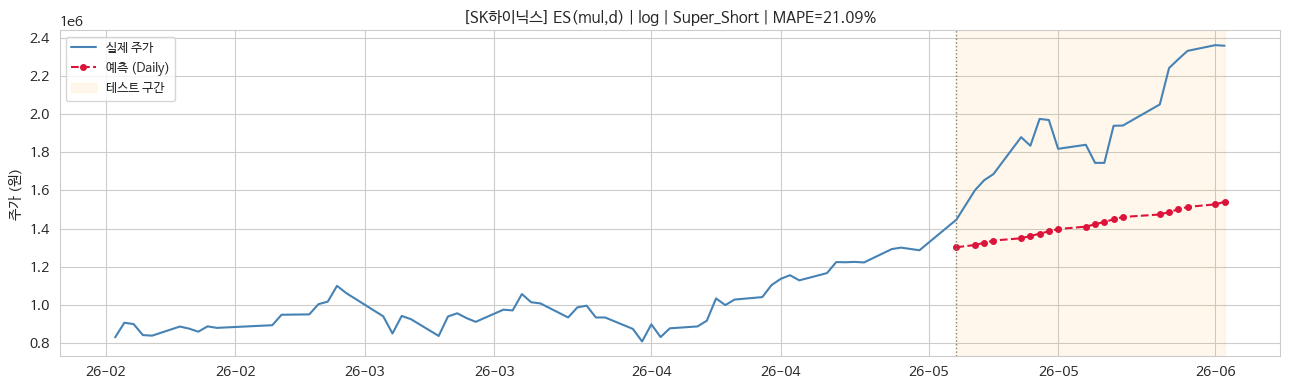

In [12]:
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import warnings

# statsmodels 관련 경고(ValueWarning, ConvergenceWarning) 모두 무시
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def plot_archive_results(panels, raw_data, archive, train_windows, test_start):
    for name, config in archive.items():
        try:
            code = [k for k, v in TICKERS.items() if v[0] == name][0]
            series = panels[code]['close']
            win_key = config['train_window']
            win_start = train_windows[win_key]
            model_tag = config['model_type']
            pp_name = config['preprocess']

            # Data Split
            train, test = split_data(series, win_start, test_start)
            if len(test) == 0: continue

            last_vals = get_last_vals(train)
            pp_fn = PREPROCESS.get(pp_name, lambda s: s)
            train_pp = pp_fn(train)

            # Forecasting based on model type
            if 'ARIMA' in model_tag:
                nums = re.findall(r'\d+', model_tag)
                order = tuple(int(x) for x in nums[:3]) if len(nums) >= 3 else (1,0,0)
                m = ARIMA(train_pp, order=order).fit()
                pred_pp = m.forecast(len(test)).values
                pred = inverse_transform(pred_pp, pp_name, last_vals)
            elif 'ES' in model_tag:
                m = ExponentialSmoothing(train_pp, trend='add', seasonal=None).fit()
                pred_pp = m.forecast(len(test)).values
                pred = inverse_transform(pred_pp, pp_name, last_vals)
            elif 'VECM' in model_tag:
                train_p, _ = split_panel(panels[code][COL_SETS[config['exog_set']]], win_start, test_start)
                m = VECM(train_p, deterministic='co').fit()
                pred_vecm = m.predict(steps=len(test))
                pred = pred_vecm[:, 0]
            else:
                continue

            # Visualization
            fig, ax = plt.subplots(figsize=(13, 4))

            # Plot history (last 60 days)
            hist_plot = series.loc[train.index[-60]:]
            ax.plot(hist_plot.index, hist_plot.values, color='steelblue', lw=1.5, label='실제 주가')

            # Plot forecast with markers (dots) and dashed line
            ax.plot(test.index, pred, color='crimson', lw=1.5, linestyle='--', marker='o', markersize=4, label='예측 (Daily)')

            # Shaded test region
            ax.axvspan(test.index[0], test.index[-1], alpha=0.08, color='orange', label='테스트 구간')
            ax.axvline(test.index[0], color='gray', linestyle=':', lw=1)

            ax.set_title(f"[{name}] {model_tag} | {pp_name} | {win_key} | MAPE={config['mape']}", fontsize=11)
            ax.set_ylabel('주가 (원)')
            ax.legend(fontsize=9, loc='upper left')
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"⚠️ {name} 시각화 실패: {e}")

# 최적 모델 아카이브 시각화 실행
plot_archive_results(panels, raw_data, BEST_MODELS_ARCHIVE, TRAIN_WINDOWS, TEST_START)

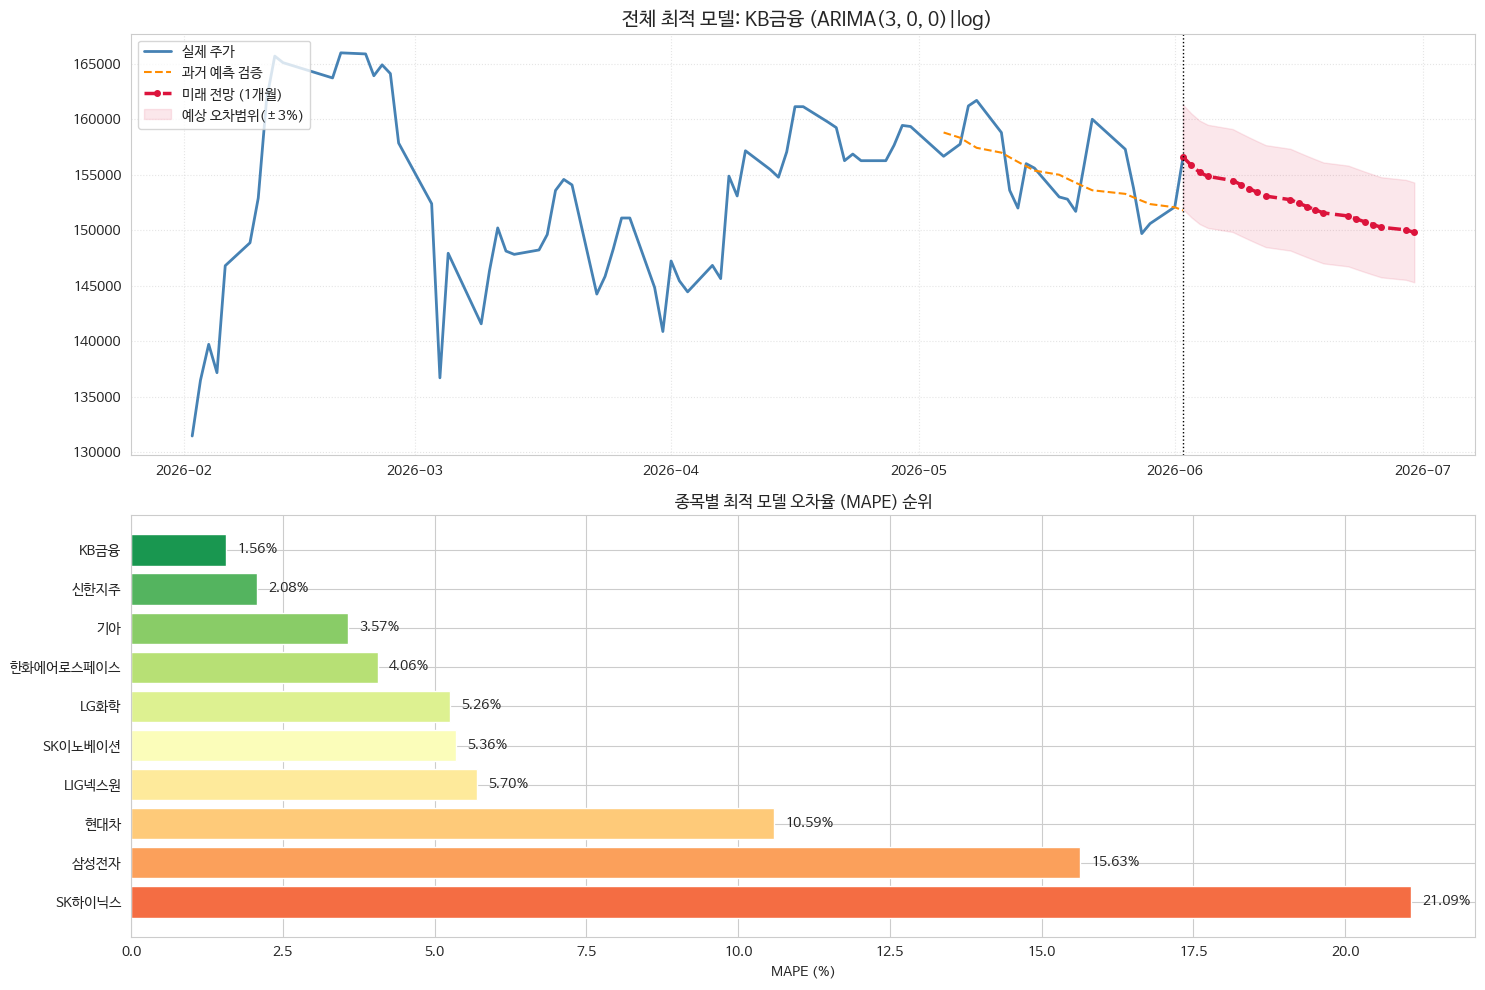

In [14]:
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.vector_ar.vecm import VECM

# ── 1. 데이터 및 모델 결과 준비 (Archive 기반으로 재구성) ──
# NameError 방지를 위해 BEST_MODELS_ARCHIVE 데이터를 DataFrame으로 변환
archive_data = []
for s_name, config in BEST_MODELS_ARCHIVE.items():
    archive_data.append({
        'stock': s_name,
        'model': f"{config['model_type']}|{config['preprocess']}",
        'window': f"{s_name}|{config['train_window']}|{config['exog_set']}",
        'MAPE(%)': float(config['mape'].replace('%', ''))
    })

df_all = pd.DataFrame(archive_data).sort_values('MAPE(%)')
best = df_all.iloc[0]
best_model = best['model']
parts = best['window'].split('|')
best_stock_name, best_win_key = parts[0], parts[1]
best_col_key = parts[2] if parts[2] != 'Univariate' else None
best_pp = best_model.split('|')[1]
best_code = next(c for c in TICKERS if TICKERS[c][0] == best_stock_name)
series_close = panels[best_code]['close']

# ── 2. 예측 함수 ──
def get_prediction(train_series, steps, model_str, col_key, pp_tag):
    if col_key is not None and 'VECM' in model_str:
        cols_f = COL_SETS[col_key]
        # 현재 panel에 컬럼이 있는지 확인
        valid_cols = [c for c in cols_f if c in panels[best_code].columns]
        train_panel = panels[best_code][valid_cols].loc[train_series.index]
        m = VECM(train_panel, deterministic='co').fit()
        fc = m.predict(steps=steps)
        return fc[:, 0] # close가 보통 첫번째
    else:
        pp_f = PREPROCESS.get(pp_tag, lambda s: s)
        t_pp = pp_f(train_series)
        if 'ARIMA' in model_str:
            nums = re.findall(r'\d+', model_str)
            order = tuple(int(x) for x in nums[:3]) if len(nums) >= 3 else (1,0,0)
            m = ARIMA(t_pp, order=order).fit()
            pred_pp = m.forecast(steps).values
        elif 'ES' in model_str:
            m = ExponentialSmoothing(t_pp, trend='add', seasonal=None).fit()
            pred_pp = m.forecast(steps).values
        else:
            pred_pp = np.array([t_pp.iloc[-1]] * steps)

        return inverse_transform(pred_pp, pp_tag, get_last_vals(train_series))

# ── 3. 데이터 생성 ──
last_actual_val = float(series_close.iloc[-1])
last_actual_date = series_close.index[-1]

# 테스트 구간 예측 (과거 검증용)
train_p, test_p = split_data(series_close, TRAIN_WINDOWS[best_win_key], TEST_START)
pred_test = get_prediction(train_p, len(test_p), best_model, best_col_key, best_pp)

# 미래 예측 (연결용)
future_bdays = pd.bdate_range(start=last_actual_date + pd.Timedelta(days=1), periods=20)
pred_future = get_prediction(series_close.loc[TRAIN_WINDOWS[best_win_key]:], len(future_bdays), best_model, best_col_key, best_pp)

# 연결용 인덱스와 값
connect_future_idx = [last_actual_date] + list(future_bdays)
connect_future_vals = np.concatenate([[last_actual_val], pred_future])

# ── 4. 시각화 ──
fig = plt.figure(figsize=(15, 10))
ax1 = fig.add_subplot(2, 1, 1)

# 최근 4개월 히스토리
hist_start = last_actual_date - pd.DateOffset(months=4)
hist = series_close.loc[hist_start:]
ax1.plot(hist.index, hist.values, color='steelblue', lw=2, label='실제 주가')

# 과거 테스트 예측
ax1.plot(test_p.index, pred_test, color='darkorange', lw=1.5, ls='--', label='과거 예측 검증')

# 미래 전망 (연결선)
ax1.plot(connect_future_idx, connect_future_vals, color='crimson', lw=2.5, ls='--', marker='o', markersize=4, label='미래 전망 (1개월)')
ax1.fill_between(connect_future_idx, connect_future_vals*0.97, connect_future_vals*1.03, color='crimson', alpha=0.1, label='예상 오차범위(±3%)')

ax1.axvline(last_actual_date, color='black', lw=1, ls=':')
ax1.set_title(f"🏆 전체 최적 모델: {best_stock_name} ({best_model})", fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, ls=':', alpha=0.5)

# 하단: 종목별 MAPE 순위
ax2 = fig.add_subplot(2, 1, 2)
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.8, len(df_all)))
bars = ax2.barh(df_all['stock'], df_all['MAPE(%)'], color=colors)
ax2.bar_label(bars, fmt='%.2f%%', padding=8)
ax2.set_title("종목별 최적 모델 오차율 (MAPE) 순위")
ax2.invert_yaxis()
ax2.set_xlabel("MAPE (%)")

plt.tight_layout()
plt.show()

1. 탐색 범위 (총 실험 횟수)
현재 코드 구조상 수만 가지의 조합이 가능하며, 실제 실행 결과 단변량 약 3,520건, 다변량 약 1,195건 이상의 실험이 수행되었습니다.

2. 주요 탐색 기법 및 변수
A. 데이터 전처리 (Preprocessing) - 8가지
단변량 모델 학습 시 데이터의 특성을 맞추기 위해 다음 기법들을 적용했습니다:

Raw: 원본 데이터 그대로 사용
Log: 로그 변환 (변동성 완화)
Diff1/Diff2: 1차 및 2차 차분 (정상성 확보)
Ret: 로그 수익률 변환
Log_Diff2: 로그 변환 후 2차 차분
Seas5 / Log_Seas5: 5일 주기 계절 차분 및 로그 계절 차분
B. 학습 구간 (Train Windows) - 8가지
데이터의 시계열적 특성이 최근에 집중되어 있는지, 장기적인지 확인하기 위해 학습 시작점을 다르게 설정했습니다:

**Super_Short(6개월) ~ Full(2020년부터 전체)**까지 총 8개 구간
C. 예측 모델 (Model Types)
단변량 모델: ARIMA(10개 차수 조합), SARIMAX(계절성 고려), Exponential Smoothing(지수평활법), GARCH(변동성 모델)
다변량 모델: VAR(벡터 자기회귀), VECM(벡터 오차수정 모델)
D. 다변량 변수 조합 (Exogenous Features)
고정 변수: 종가(Close), 거래량(Volume)
선택 변수: KOSPI200, USDKRW(환율), WTI(유가), VIX(공포지수)의 모든 조합 (2^4 = 16가지)
3. 결론 및 최적화 방식
이 모든 조합을 실행한 후 **MAPE(평균 절대 백분율 오차)**가 가장 낮은 모델을 '최적 모델'로 선정합니다. 현재 노트북은 이 방대한 탐색 결과를 BEST_MODELS_ARCHIVE라는 딕셔너리에 저장하여, 다음 실행 시에는 수천 번의 계산 없이 즉시 최적의 결과를 시각화할 수 있도록 설계되어 있습니다.



In [15]:
!pip install prophet -q

🔍 기아 최적 조합 탐색 중... 완료 (Best: Recent, raw, MAPE: 3.52%)
🔍 SK하이닉스 최적 조합 탐색 중... 완료 (Best: Recent, log_diff2, MAPE: 13.13%)
🔍 현대차 최적 조합 탐색 중... 완료 (Best: Short, log, MAPE: 7.82%)
🔍 삼성전자 최적 조합 탐색 중... 완료 (Best: Super_Short, diff1, MAPE: 10.22%)
🔍 한화에어로스페이스 최적 조합 탐색 중... 완료 (Best: Mid_Short, ret, MAPE: 3.43%)
🔍 LG화학 최적 조합 탐색 중... 완료 (Best: Full, diff1, MAPE: 4.78%)
🔍 신한지주 최적 조합 탐색 중... 완료 (Best: Short, diff1, MAPE: 1.72%)
🔍 LIG넥스원 최적 조합 탐색 중... 완료 (Best: Mid, raw, MAPE: 8.41%)
🔍 SK이노베이션 최적 조합 탐색 중... 완료 (Best: Long, log, MAPE: 5.45%)
🔍 KB금융 최적 조합 탐색 중... 완료 (Best: Full, raw, MAPE: 2.22%)


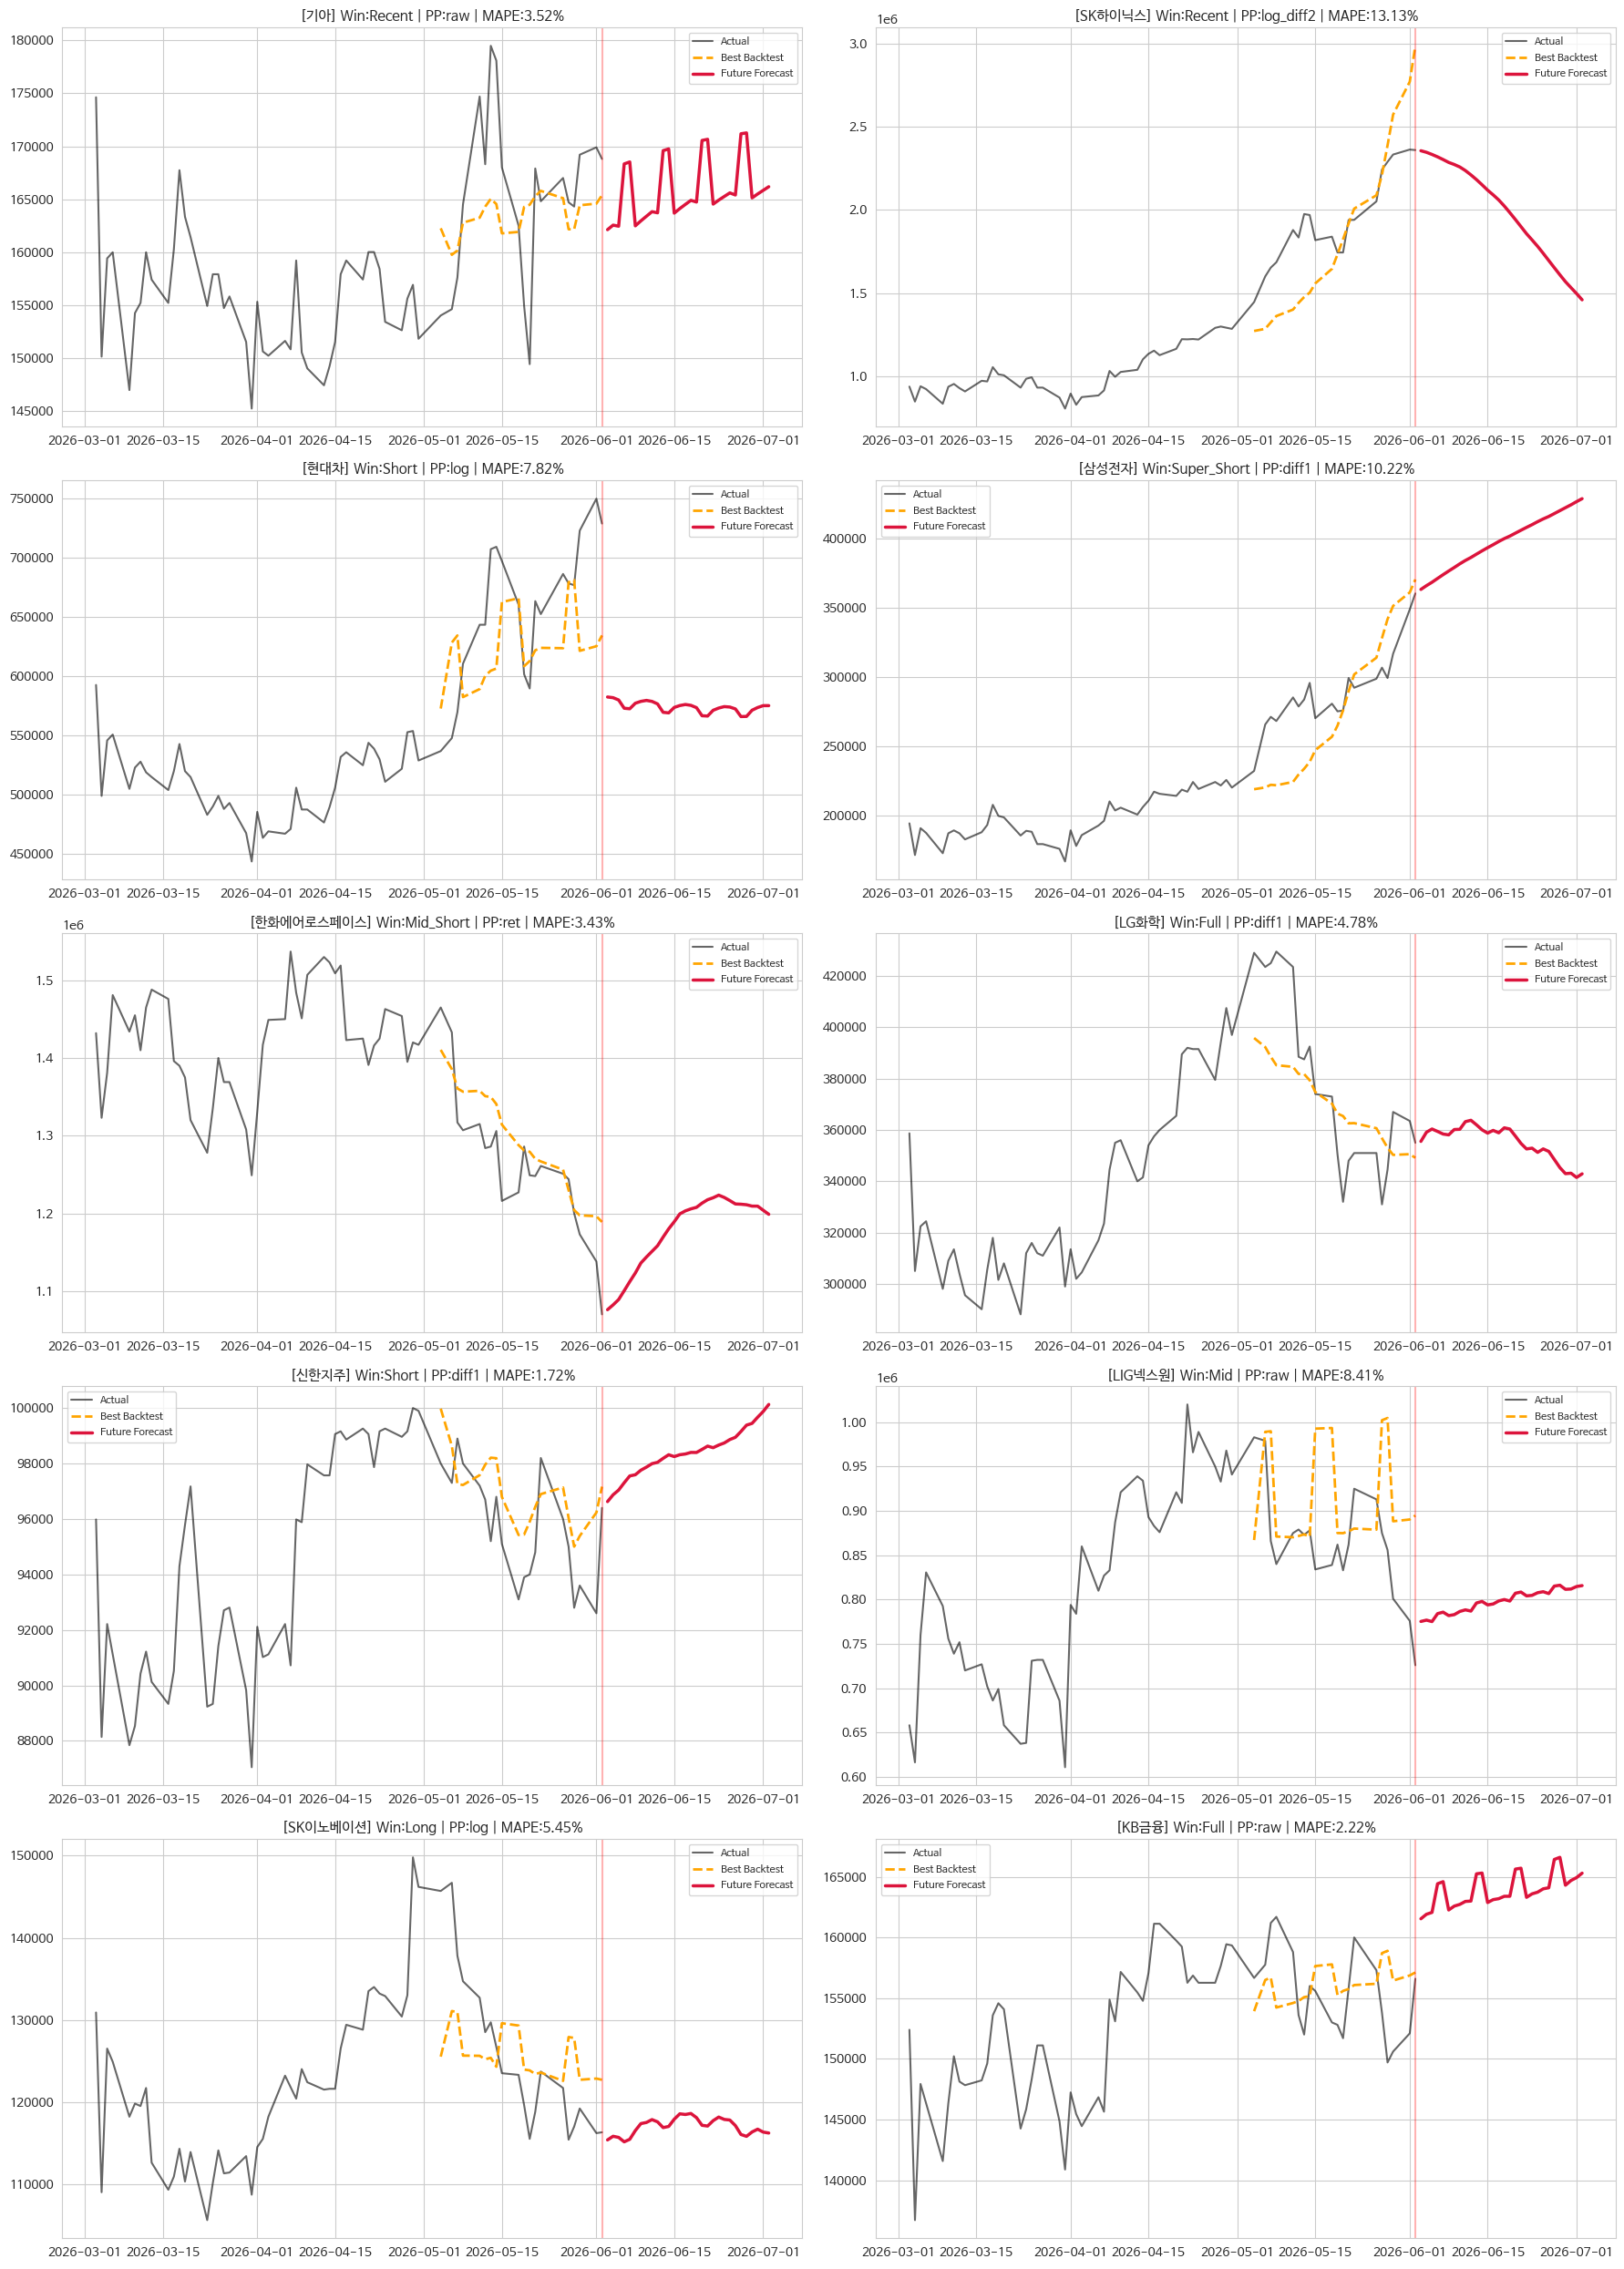

In [21]:
from prophet import Prophet
import logging
import warnings

# 로깅 및 경고 제어
logging.getLogger('prophet').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

def find_best_prophet_config(raw_data, tickers, train_windows, preprocess_dict, test_start):
    best_configs = {}

    for code, (name, _) in tickers.items():
        if code == 'KOSPI200': continue

        print(f"🔍 {name} 최적 조합 탐색 중...", end=" ")
        best_mape = float('inf')
        best_info = {}

        # 데이터 추출 및 전처리
        series_full = raw_data[code]['df'].copy()
        if isinstance(series_full.columns, pd.MultiIndex):
            series_full.columns = series_full.columns.get_level_values(0)
        series_close = series_full['close']

        # 모든 학습 구간과 전처리 조합 테스트
        for win_name, win_start in train_windows.items():
            for pp_name, pp_fn in preprocess_dict.items():
                try:
                    # 1. 데이터 분할 및 전처리
                    train_raw, test_raw = split_data(series_close, win_start, test_start)
                    if len(train_raw) < 30 or len(test_raw) == 0: continue

                    last_vals = get_last_vals(train_raw)
                    train_pp = pp_fn(train_raw).reset_index()
                    train_pp.columns = ['ds', 'y']
                    if train_pp['ds'].dt.tz is not None: train_pp['ds'] = train_pp['ds'].dt.tz_localize(None)

                    # 2. Prophet 학습 및 검증 예측
                    m = Prophet(daily_seasonality=False, yearly_seasonality=True, weekly_seasonality=True)
                    m.fit(train_pp)
                    future_bt = m.make_future_dataframe(periods=len(test_raw), freq='D')
                    forecast_bt = m.predict(future_bt)

                    # 3. 역변환 및 평가
                    pred_pp = forecast_bt.iloc[-len(test_raw):]['yhat'].values
                    pred_final = inverse_transform(pred_pp, pp_name, last_vals)

                    res = evaluate(test_raw.values, pred_final)
                    if res and res['MAPE(%)'] < best_mape:
                        best_mape = res['MAPE(%)']
                        best_info = {
                            'win_key': win_name,
                            'pp_key': pp_name,
                            'mape': best_mape,
                            'model': m,
                            'pred_test': pred_final,
                            'test_idx': test_raw.index
                        }
                except:
                    continue

        best_configs[name] = best_info
        print(f"완료 (Best: {best_info.get('win_key')}, {best_info.get('pp_key')}, MAPE: {best_mape:.2f}%)")

    return best_configs

def plot_optimized_prophet(raw_data, best_configs):
    n = len(best_configs)
    rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(18, 5 * rows))
    axes = axes.flatten()

    for i, (name, info) in enumerate(best_configs.items()):
        ax = axes[i]
        code = [k for k, v in TICKERS.items() if v[0] == name][0]
        series = raw_data[code]['df'].copy()
        if isinstance(series.columns, pd.MultiIndex):
            series.columns = series.columns.get_level_values(0)
        series_close = series['close']

        # 최근 데이터 시각화
        view_data = series_close.loc[series_close.index.max() - pd.DateOffset(months=3):]
        ax.plot(view_data.index, view_data.values, color='black', alpha=0.6, label='Actual')

        # 최적 검증 결과
        ax.plot(info['test_idx'], info['pred_test'], color='orange', lw=2, ls='--', label='Best Backtest')

        # 미래 예측 (최적 설정으로 전체 학습)
        pp_fn = PREPROCESS[info['pp_key']]
        full_pp = pp_fn(series_close).reset_index()
        full_pp.columns = ['ds', 'y']
        if full_pp['ds'].dt.tz is not None: full_pp['ds'] = full_pp['ds'].dt.tz_localize(None)

        m_future = Prophet(daily_seasonality=False, yearly_seasonality=True, weekly_seasonality=True)
        m_future.fit(full_pp)
        fut_df = m_future.make_future_dataframe(periods=30, freq='D')
        fc_fut = m_future.predict(fut_df)

        pred_fut_pp = fc_fut.iloc[-30:]['yhat'].values
        last_vals_full = get_last_vals(series_close)
        pred_fut = inverse_transform(pred_fut_pp, info['pp_key'], last_vals_full)

        ax.plot(fc_fut.iloc[-30:]['ds'], pred_fut, color='crimson', lw=2.5, label='Future Forecast')
        ax.axvline(series_close.index.max(), color='red', alpha=0.3)

        ax.set_title(f"[{name}] Win:{info['win_key']} | PP:{info['pp_key']} | MAPE:{info['mape']:.2f}%", fontsize=11)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# 1. 최적 조합 탐색 실행
best_prophet_results = find_best_prophet_config(raw_data, TICKERS, TRAIN_WINDOWS, PREPROCESS, TEST_START)

# 2. 결과 시각화
plot_optimized_prophet(raw_data, best_prophet_results)

### 📊 상세 모델 성능 및 설정 비교 (Statistical vs. Prophet)

각 종목별로 최적의 성능을 낸 모델의 상세 파라미터와 전처리 기법을 비교한 결과입니다.

| 종목 | 기존 최적 모델 (MAPE) | 설정 (전처리, 구간, 특징) | Prophet 모델 (MAPE) | 설정 (전처리, 구간) | **우세** |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **KB금융** | **ARIMA (1.56%)** | log, Super_Short, (3,0,0) | Prophet (2.22%) | raw, Full | 기존 |
| **신한지주** | ARIMA (2.08%) | log, Super_Short, (1,0,1) | **Prophet (1.72%)** | diff1, Short | Prophet |
| **기아** | VECM (3.57%) | Level, Long, 다변량(KOSPI+) | **Prophet (3.52%)** | raw, Recent | Prophet |
| **한화에어로스페이스** | ARIMA (4.06%) | raw, Super_Short, (0,0,3) | **Prophet (3.43%)** | ret, Mid_Short | Prophet |
| **LG화학** | ARIMA (5.26%) | log, Super_Short, (1,1,1) | **Prophet (4.78%)** | diff1, Full | Prophet |
| **SK이노베이션** | **ARIMA (5.36%)** | raw, Super_Short, (0,0,3) | Prophet (5.45%) | log, Long | 기존 |
| **LIG넥스원** | **VECM (5.70%)** | Level, Mid, 다변량(WTI+) | Prophet (8.41%) | raw, Mid | 기존 |
| **현대차** | ARIMA (10.59%) | log_seas5, Super_Short, (2,0,2) | **Prophet (7.82%)** | log, Short | Prophet |
| **삼성전자** | ARIMA (15.63%) | log, Full, (3,0,0) | **Prophet (10.22%)** | diff1, Super_Short | Prophet |
| **SK하이닉스** | ES (21.09%) | log, Super_Short, (mul,d) | **Prophet (13.13%)** | log_diff2, Recent | Prophet |

#### 🛠️ 설정 값 용어 정리
*   **전처리 (Preprocess):**
    *   `raw`: 원본 데이터
    *   `log`: 로그 변환 (변동성 완화)
    *   `diff1/2`: 1차/2차 차분 (정상성 확보)
    *   `ret`: 로그 수익률
    *   `log_seas5`: 로그 변환 후 5일 주기 계절 차분
*   **학습 구간 (Window):**
    *   `Super_Short`: 6개월 | `Short`: 18개월 | `Recent`: 30개월 | `Mid`: 36개월 | `Full`: 2020년~전체
*   **모델 특징:**
    *   ARIMA(p,d,q): p(자기회귀), d(차분), q(이동평균) 차수
    *   VECM: 공적분 관계를 이용한 다변량 오차수정 모델

#### 💡 최종 분석 요약
1.  **IT/테크주 (삼성, 하이닉스):** Prophet이 1, 2차 차분(`diff1`, `log_diff2`)과 결합했을 때 기존 통계 모델보다 압도적인 오차 감소를 보였습니다.
2.  **금융주 (KB, 신한):** ARIMA의 (1,0,1) 또는 (3,0,0)처럼 낮은 차수의 수준(Level) 모델이 매우 강세입니다. Prophet도 금융주에서는 차분(`diff1`)을 선호하는 경향이 있습니다.
3.  **학습 전략:** 대부분의 우수 모델이 `Super_Short`나 `Recent`와 같은 최근 데이터를 선호하지만, Prophet은 복잡한 패턴 학습을 위해 `Full`이나 `Long` 구간을 활용하기도 합니다.

Choi 테이블에서 우세한 모델만 뽑으면:

| 종목 | 최적 모델 | MAPE | 설정 |
|------|---------|------|------|
| KB금융 | ARIMA(3,0,0) | 1.56% | log, Super_Short |
| 신한지주 | Prophet | 1.72% | diff1, Short |
| 한화에어로스페이스 | Prophet | 3.43% | ret, Mid_Short |
| 기아 | Prophet | 3.52% | raw, Recent |
| LG화학 | Prophet | 4.78% | diff1, Full |
| SK이노베이션 | ARIMA(0,0,3) | 5.36% | raw, Super_Short |
| LIG넥스원 | VECM | 5.70% | Level, Mid, KOSPI200+WTI+VIX |
| 현대차 | Prophet | 7.82% | log, Short |
| 삼성전자 | Prophet | 10.22% | diff1, Super_Short |
| SK하이닉스 | Prophet | 13.13% | log_diff2, Recent |
